In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
import os
import pandas as pd
data_path = '../data'

folders = ['anomaly-free', 'valve1', 'valve2', 'other']

all_dataframes = []

for folder_name in folders:
    folder_path = os.path.join(data_path, folder_name)
    
    if not os.path.exists(folder_path):
        print(f"Missing folder: {folder_path}")
        continue
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            
            try:
                df = pd.read_csv(file_path, sep=';', parse_dates=['datetime'])
                df['anomaly_source'] = folder_name
                df['filename'] = filename
                all_dataframes.append(df)
                
            except Exception as e:
                print(f"Error reading: {file_path}")
                print(e)

combined_df = pd.concat(all_dataframes, ignore_index=True)

print(f"Total rows: {len(combined_df)}")
print(f"Total columns: {len(combined_df.columns)}")
print(f"Columns: {list(combined_df.columns)}")

Total rows: 44534
Total columns: 13
Columns: ['datetime', 'Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly_source', 'filename', 'anomaly', 'changepoint']


In [4]:
for col in combined_df.columns:
    print(col)

datetime
Accelerometer1RMS
Accelerometer2RMS
Current
Pressure
Temperature
Thermocouple
Voltage
Volume Flow RateRMS
anomaly_source
filename
anomaly
changepoint


In [5]:
combined_df.head(10)

,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly_source,filename,anomaly,changepoint
0,2020-02-08 13:30:47,0.202394,0.275154,2.16975,0.382638,90.6454,26.8508,238.852,122.664,anomaly-free,anomaly-free.csv,NaN,NaN
1,2020-02-08 13:30:48,0.203153,0.277857,2.07999,-0.273216,90.7978,26.8639,227.943,122.338,anomaly-free,anomaly-free.csv,NaN,NaN
2,2020-02-08 13:30:50,0.202054,0.275790,2.52577,0.382638,90.7730,26.8603,223.486,121.338,anomaly-free,anomaly-free.csv,NaN,NaN
3,2020-02-08 13:30:51,0.203595,0.278101,2.49742,0.054711,90.8424,26.8616,244.904,121.664,anomaly-free,anomaly-free.csv,NaN,NaN
4,2020-02-08 13:30:52,0.201889,0.276363,2.29194,0.710565,90.6664,26.8603,239.196,122.000,anomaly-free,anomaly-free.csv,NaN,NaN
5,2020-02-08 13:30:53,0.203646,0.277887,2.57094,0.054711,90.7608,26.8723,240.549,121.338,anomaly-free,anomaly-free.csv,NaN,NaN
6,2020-02-08 13:30:54,0.201434,0.278046,3.10397,0.054711,90.7526,26.8573,251.862,121.664,anomaly-free,anomaly-free.csv,NaN,NaN
7,2020-02-08 13:30:55,0.201625,0.276807,2.40694,0.054711,90.9229,26.8573,228.402,122.000,anomaly-free,anomaly-free.csv,NaN,NaN
8,2020-02-08 13:30:56,0.202689,0.276321,2.56711,-0.601143,90.9333,26.8676,226.631,122.000,anomaly-free,anomaly-free.csv,NaN,NaN
9,2020-02-08 13:30:57,0.200964,0.276530,2.46020,0.054711,90.7807,26.8673,218.205,122.000,anomaly-free,anomaly-free.csv,NaN,NaN


In [6]:
print("Shape of dataset:")
print(f"Rows: {combined_df.shape[0]}")
print(f"Columns: {combined_df.shape[1]}")

print("\nData types of each column:")
print(combined_df.dtypes)

print("\nBasic statistics of sensor columns:")
combined_df[['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 
             'Pressure', 'Temperature', 'Thermocouple', 
             'Voltage', 'Volume Flow RateRMS']].describe()

Shape of dataset:
Rows: 44534
Columns: 13

Data types of each column:
datetime               datetime64[ns]
Accelerometer1RMS             float64
Accelerometer2RMS             float64
Current                       float64
Pressure                      float64
Temperature                   float64
Thermocouple                  float64
Voltage                       float64
Volume Flow RateRMS           float64
anomaly_source                 object
filename                       object
anomaly                       float64
changepoint                   float64
dtype: object

Basic statistics of sensor columns:


,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS
count,44534.000000,44534.000000,44534.000000,44534.000000,44534.000000,44534.000000,44534.000000,44534.000000
mean,0.134487,0.169127,1.686942,0.080248,79.657793,26.611583,229.519473,77.750015
std,0.127720,0.145570,0.795284,0.259839,9.464279,2.614352,10.956228,45.502131
min,0.015752,0.015505,0.149842,-1.257000,65.188700,22.020900,200.744000,0.555512
25%,0.027499,0.040561,1.002005,0.054711,69.519625,24.655600,223.516500,32.000000
50%,0.081096,0.132301,1.450505,0.054711,85.365800,25.539400,229.787500,76.000000
75%,0.216333,0.269425,2.502935,0.382638,88.667975,29.175775,235.880000,126.000000
max,0.722747,0.800498,3.318370,1.694350,95.011400,33.415100,255.112000,133.688000


In [7]:
print("Missing values in each column:")
print(combined_df.isnull().sum())

print("\nPercentage of missing values:")
print((combined_df.isnull().sum() / len(combined_df) * 100).round(2))

Missing values in each column:
datetime                  0
Accelerometer1RMS         0
Accelerometer2RMS         0
Current                   0
Pressure                  0
Temperature               0
Thermocouple              0
Voltage                   0
Volume Flow RateRMS       0
anomaly_source            0
filename                  0
anomaly                9405
changepoint            9405
dtype: int64

Percentage of missing values:
datetime                0.00
Accelerometer1RMS       0.00
Accelerometer2RMS       0.00
Current                 0.00
Pressure                0.00
Temperature             0.00
Thermocouple            0.00
Voltage                 0.00
Volume Flow RateRMS     0.00
anomaly_source          0.00
filename                0.00
anomaly                21.12
changepoint            21.12
dtype: float64


In [8]:
combined_df['anomaly'] = combined_df['anomaly'].fillna(0)
combined_df['changepoint'] = combined_df['changepoint'].fillna(0)

print("Missing values after fixing:")
print(combined_df[['anomaly', 'changepoint']].isnull().sum())

print("\nAnomaly value counts:")
print(combined_df['anomaly'].value_counts())

print("\nAnomaly percentage:")
total = len(combined_df)
anomaly_count = combined_df['anomaly'].sum()
normal_count = total - anomaly_count
print(f"Normal rows: {int(normal_count)} ({round(normal_count/total*100, 2)}%)")
print(f"Anomaly rows: {int(anomaly_count)} ({round(anomaly_count/total*100, 2)}%)")

Missing values after fixing:
anomaly        0
changepoint    0
dtype: int64

Anomaly value counts:
anomaly
0.0    32262
1.0    12272
Name: count, dtype: int64

Anomaly percentage:
Normal rows: 32262 (72.44%)
Anomaly rows: 12272 (27.56%)


## Dataset class distribution

The combined dataset contains 44,534 readings across 33 experiments.
72.44% of readings are normal and 27.56% are anomalous.

This class imbalance means accuracy is not a reliable evaluation metric.
A model predicting all readings as normal would achieve 72.44% accuracy
while detecting zero anomalies. Therefore F1 score is used as the
primary evaluation metric as it balances precision and recall.

In [9]:
print("Rows per anomaly source:")
print(combined_df.groupby('anomaly_source')['anomaly'].agg(['count', 'sum']).rename(columns={'count': 'total_rows', 'sum': 'anomaly_rows'}))

print("\nAnomaly percentage per source:")
source_stats = combined_df.groupby('anomaly_source')['anomaly'].agg(['count', 'sum'])
source_stats['normal_rows'] = source_stats['count'] - source_stats['sum']
source_stats['anomaly_pct'] = (source_stats['sum'] / source_stats['count'] * 100).round(2)
print(source_stats[['count', 'normal_rows', 'sum', 'anomaly_pct']].rename(
    columns={'count': 'total', 'sum': 'anomalies', 'anomaly_pct': 'anomaly_%'}))

Rows per anomaly source:
                total_rows  anomaly_rows
anomaly_source                          
anomaly-free          9405           0.0
other                14929        5241.0
valve1               17013        5908.0
valve2                3187        1123.0

Anomaly percentage per source:
                total  normal_rows  anomalies  anomaly_%
anomaly_source                                          
anomaly-free     9405       9405.0        0.0       0.00
other           14929       9688.0     5241.0      35.11
valve1          17013      11105.0     5908.0      34.73
valve2           3187       2064.0     1123.0      35.24


## Anomaly source breakdown

The dataset contains four experiment categories.
The anomaly-free folder contains 9,405 rows of pure normal operation.

All three fault categories show remarkably consistent anomaly rates:
- valve1: 34.73% anomalous
- valve2: 35.24% anomalous  
- other: 35.11% anomalous

This consistency suggests the experiments were designed with
approximately one third of each run being anomalous.
This balance across fault types means our models will be
evaluated against diverse anomaly patterns.

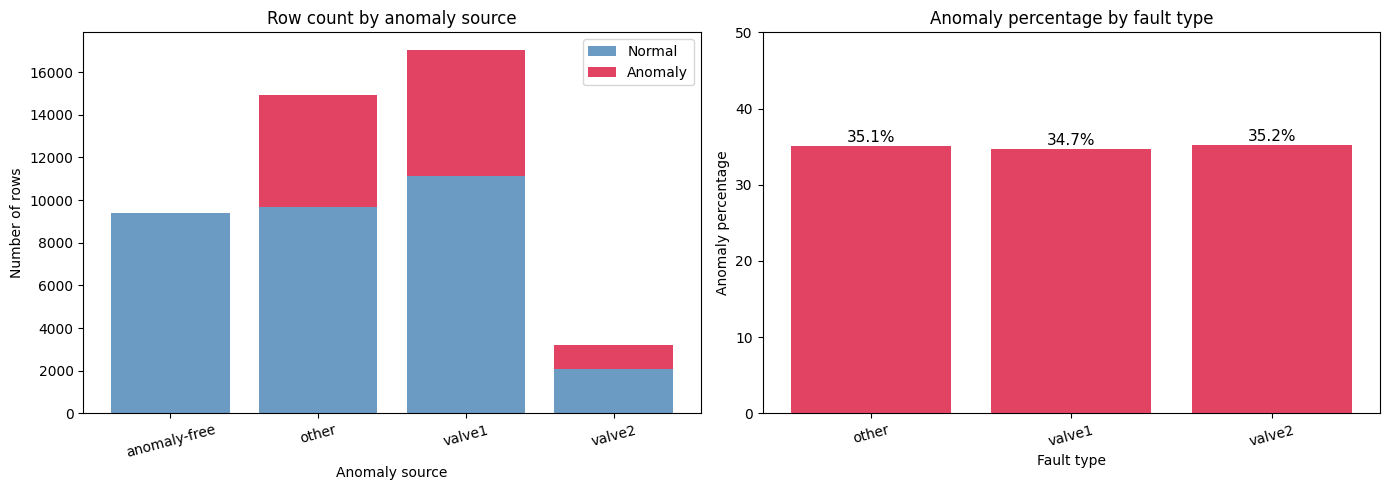

Chart saved to report folder


In [10]:
import matplotlib.pyplot as plt

source_counts = combined_df.groupby('anomaly_source')['anomaly'].agg(['count', 'sum'])
source_counts.columns = ['total', 'anomalies']
source_counts['normal'] = source_counts['total'] - source_counts['anomalies']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(source_counts.index, source_counts['normal'], 
            label='Normal', color='steelblue', alpha=0.8)
axes[0].bar(source_counts.index, source_counts['anomalies'], 
            bottom=source_counts['normal'],
            label='Anomaly', color='crimson', alpha=0.8)
axes[0].set_title('Row count by anomaly source')
axes[0].set_xlabel('Anomaly source')
axes[0].set_ylabel('Number of rows')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

anomaly_pct = (source_counts['anomalies'] / source_counts['total'] * 100).drop('anomaly-free')
axes[1].bar(anomaly_pct.index, anomaly_pct.values, color='crimson', alpha=0.8)
axes[1].set_title('Anomaly percentage by fault type')
axes[1].set_xlabel('Fault type')
axes[1].set_ylabel('Anomaly percentage')
axes[1].set_ylim(0, 50)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(anomaly_pct.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../report/anomaly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to report folder")

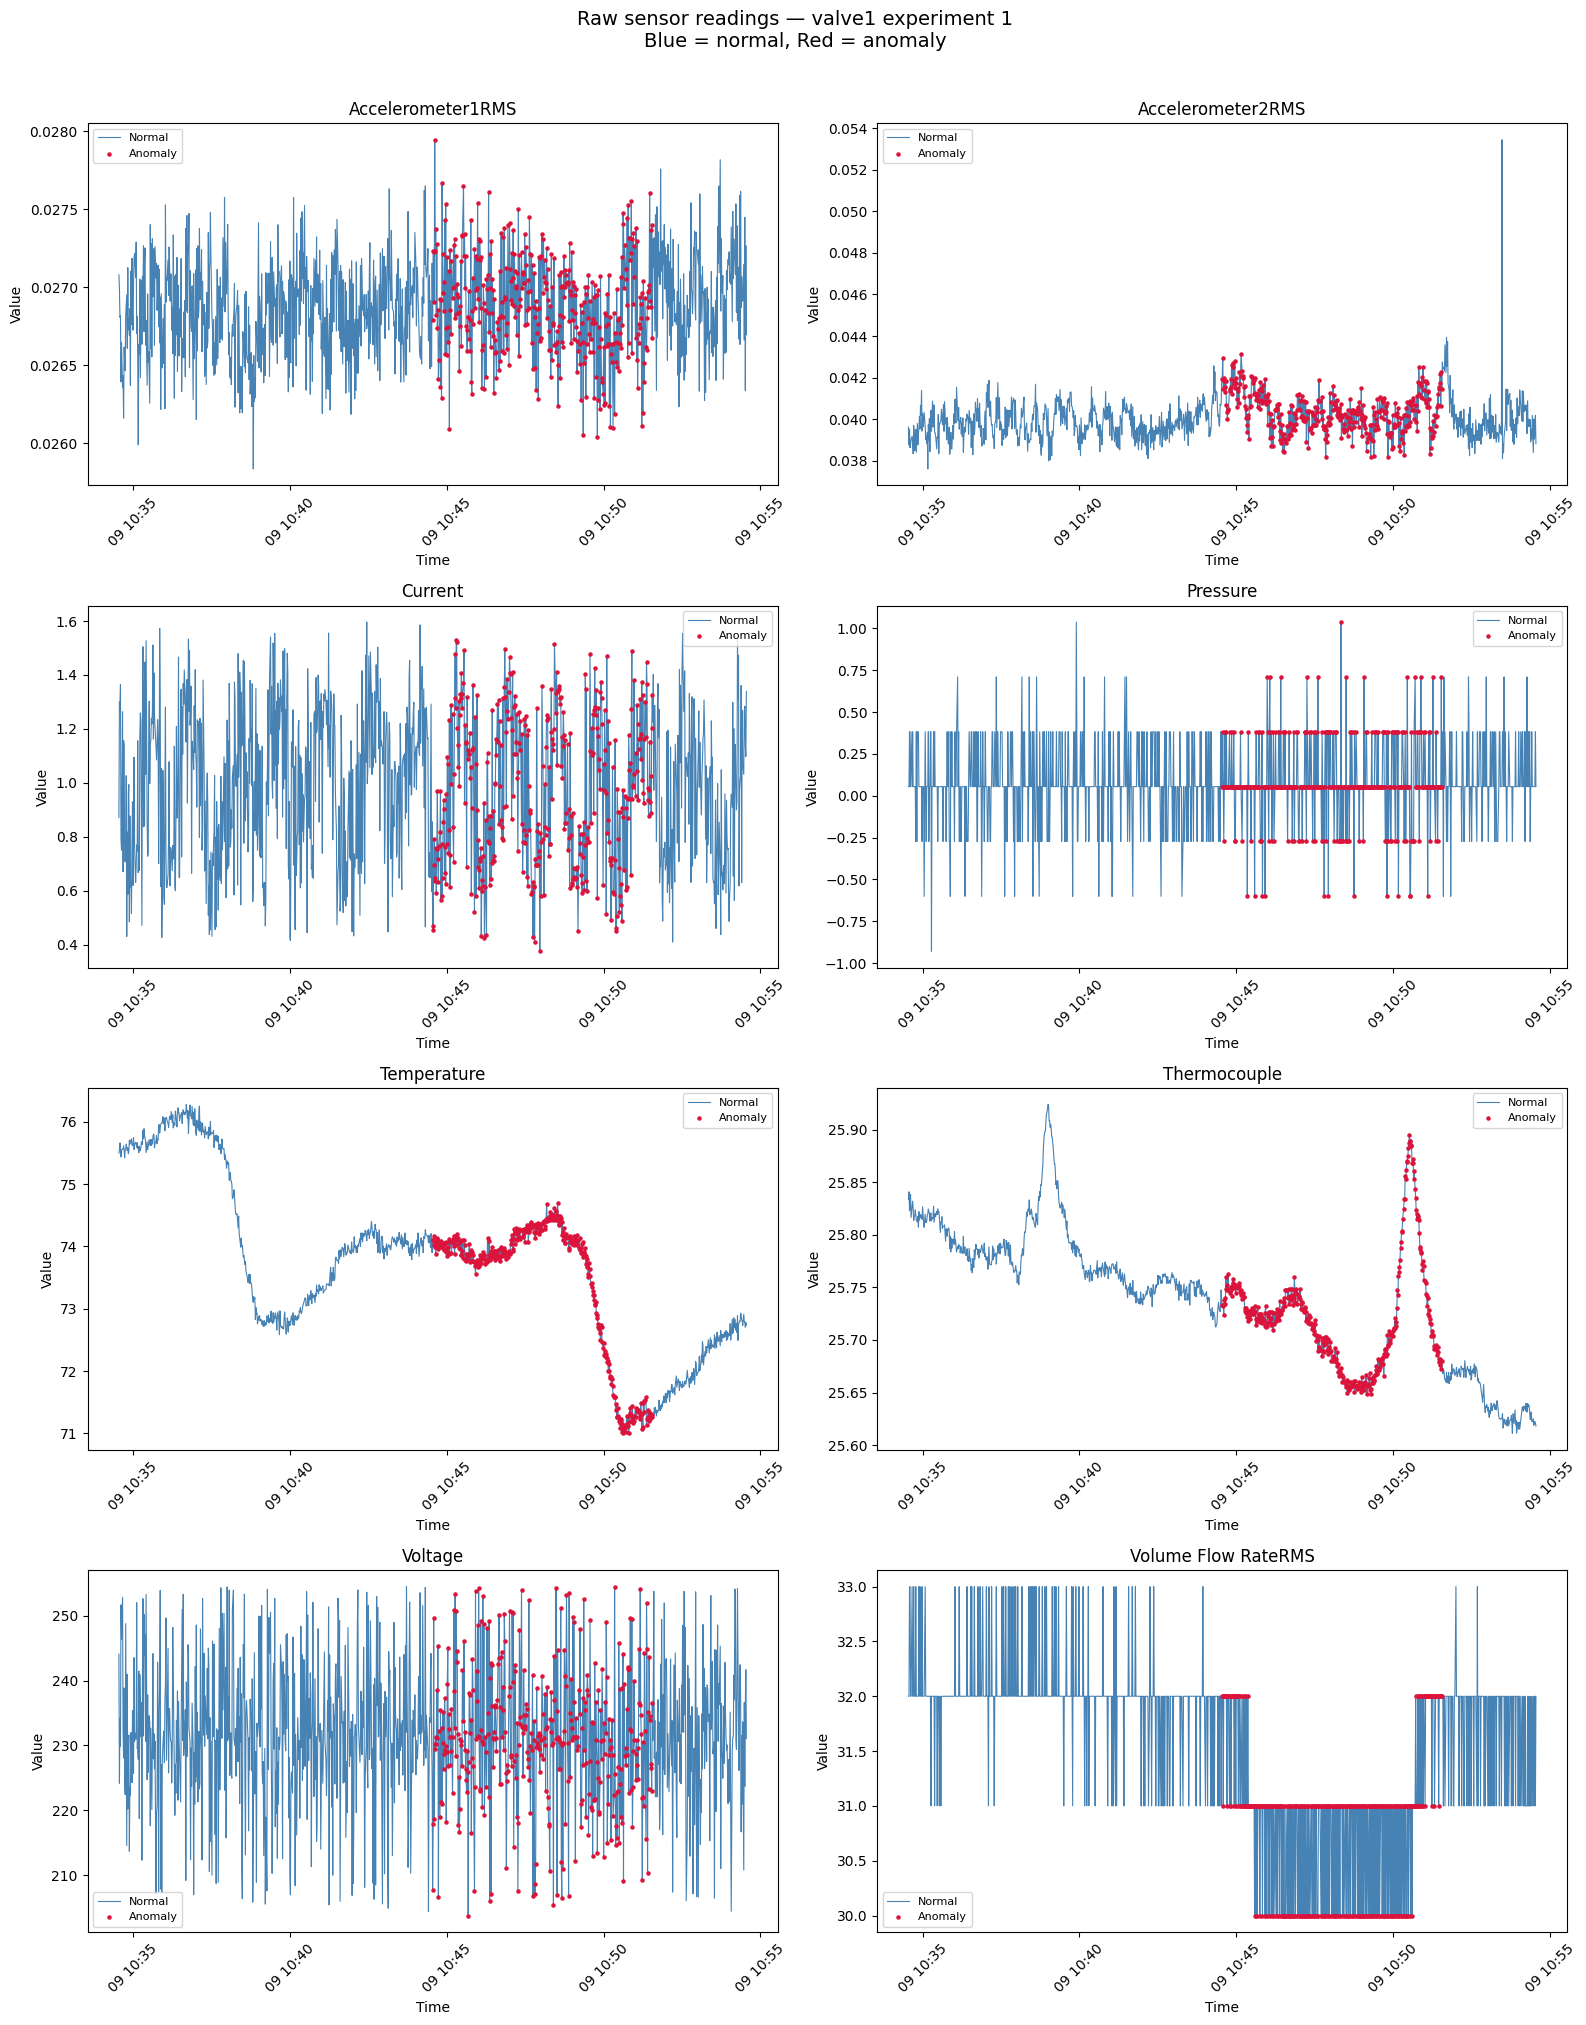

Chart saved to report folder


In [11]:
sensor_cols = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 
               'Pressure', 'Temperature', 'Thermocouple', 
               'Voltage', 'Volume Flow RateRMS']

sample_file = combined_df[combined_df['filename'] == '1.csv'][
    combined_df['anomaly_source'] == 'valve1'].copy()

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, sensor in enumerate(sensor_cols):
    axes[i].plot(sample_file['datetime'], 
                 sample_file[sensor], 
                 color='steelblue', 
                 linewidth=0.8, 
                 label='Normal')
    
    anomaly_points = sample_file[sample_file['anomaly'] == 1.0]
    axes[i].scatter(anomaly_points['datetime'],
                   anomaly_points[sensor],
                   color='crimson',
                   s=5,
                   label='Anomaly',
                   zorder=5)
    
    axes[i].set_title(f'{sensor}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Value')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Raw sensor readings — valve1 experiment 1\nBlue = normal, Red = anomaly', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../report/raw_sensor_readings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to report folder")

## Visual inspection of sensor behavior during anomalies

Raw sensor plots reveal two distinct anomaly patterns:

1. Step-change anomalies — Volume Flow RateRMS shows a sudden 
drop and sustained shift when the valve closes around 10:44. 
This type of sudden mean shift is well suited to Z-score detection.

2. Gradual drift anomalies — Temperature shows a smooth 
continuous decline during the anomalous period. This temporal 
pattern is better captured by ARIMA which models time dependencies.

This visual observation motivates our choice of two complementary 
methods — Z-score for sudden changes and ARIMA for gradual drifts.

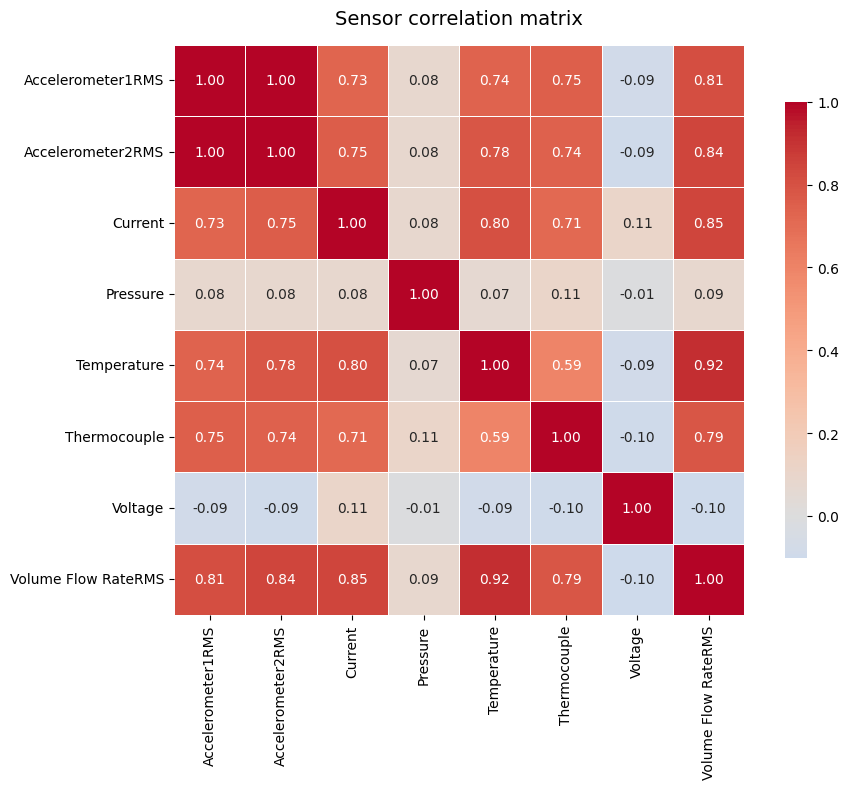

Heatmap saved to report folder


In [12]:
plt.figure(figsize=(10, 8))

correlation_matrix = combined_df[sensor_cols].corr()

sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Sensor correlation matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../report/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved to report folder")

## Sensor correlation analysis

The correlation matrix reveals four key findings:

1. Perfect vibration coupling — Accelerometer1RMS and 
Accelerometer2RMS show correlation of 1.00, indicating 
both sensors capture identical vibration events. Only one 
is needed for vibration-based anomaly detection.

2. Thermal-hydraulic coupling — Temperature and Volume Flow 
RateRMS show correlation of 0.92, the strongest inter-sensor 
relationship. Flow changes directly drive temperature changes 
through heat transfer dynamics.

3. Pressure independence — Pressure shows near-zero correlation 
with all other sensors (max 0.11). Pressure anomalies are 
independent events requiring direct monitoring.

4. Voltage opposition — Voltage shows slight negative 
correlations throughout, consistent with Ohm's law — 
increased current draw under motor load causes slight 
voltage drop.

These findings confirm that sensors measure distinct 
physical phenomena and justify monitoring all channels 
independently for anomaly detection.